# Ejercicio 1

1. Realice la carga y visualización de diferentes imágenes.
2. Muestre en pantalla información sobre las imágenes.
3. Investigue los formatos de la imagen y cómo leer y cómo escribir un valor puntual de la imagen.
4. Utilice el pasaje por parámetros para especificar la imagen a cargar.
5. Define y recorte una subimagen de una imagen (vea ROI, Region Of Interest).
6. Investigue y realice una función que le permita mostrar varias imágenes en una sóla ventana.
7. Dibuje sobre la imagen líneas, círculos y rectángulos (opcional: defina la osición en base al click del mouse).


## Cargar imágenes

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

img_bgr = cv2.imread("imagenes/firewatch.png")
img2_bgr = cv2.imread("imagenes/ow.png")

print("Dimensiones de la imagen 1: ", img_bgr.shape)
print("Tipo de dato de la imagen 1: ", img_bgr.dtype)
print("Color en [100, 100]: ", img_bgr[100, 100])

print("Dimensiones de la imagen 2: ", img2_bgr.shape)
print("Tipo de dato de la imagen 2: ", img2_bgr.dtype)
print("Color en [100, 100]: ", img_bgr[100, 100])

Dimensiones de la imagen 1:  (675, 1200, 3)
Tipo de dato de la imagen 1:  uint8
Color en [100, 100]:  [198 220 255]
Dimensiones de la imagen 2:  (1080, 1920, 3)
Tipo de dato de la imagen 2:  uint8
Color en [100, 100]:  [198 220 255]


## Modificar imágenes

In [3]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hls = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HLS)

img2_gray = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)
img2_rgb = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)
img2_hls = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2HLS)

# ROI
img_roi = img_bgr[50:400, 400:800].copy()
img2_roi = img2_bgr[400:, 1000:].copy()

# Dibujar
cv2.line(img_roi, (0,250), (400,250), (255,0,0), 5)
cv2.line(img2_roi, (400,700), (1000,300), (255,0,0), 5)
cv2.rectangle(img_roi, (100,300), (300,50), (0,255,0), 2)
cv2.rectangle(img2_roi, (650,300), (900,50), (0,255,0), 2)
cv2.circle(img_roi, (200,150), 50, (255,0,0), 2)
cv2.circle(img2_roi, (400,300), 50, (255,0,0), 2);

## Mostrar imágenes

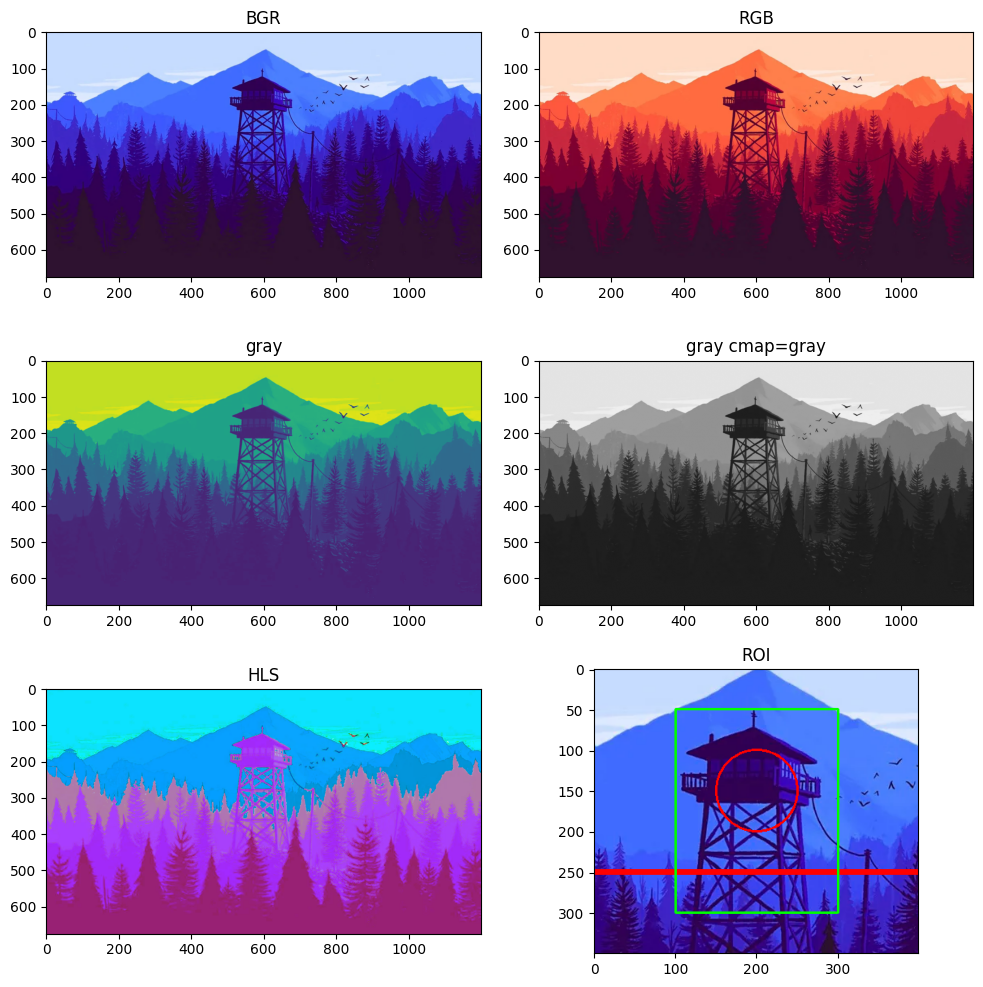

In [4]:
fig, ax = plt.subplots(3, 2)
fig.set_figwidth(10)
fig.set_figheight(10)
fig.tight_layout()

ax[0,0].set_title("BGR")
ax[0,0].imshow(img_bgr)
ax[0,1].set_title("RGB")
ax[0,1].imshow(img_rgb)
ax[1,0].set_title("gray")
ax[1,0].imshow(img_gray)
ax[1,1].set_title("gray cmap=gray")
ax[1,1].imshow(img_gray, cmap="gray", vmin=0, vmax=255)
ax[2,0].set_title("HLS")
ax[2,0].imshow(img_hls)
ax[2,1].set_title("ROI")
ax[2,1].imshow(img_roi);

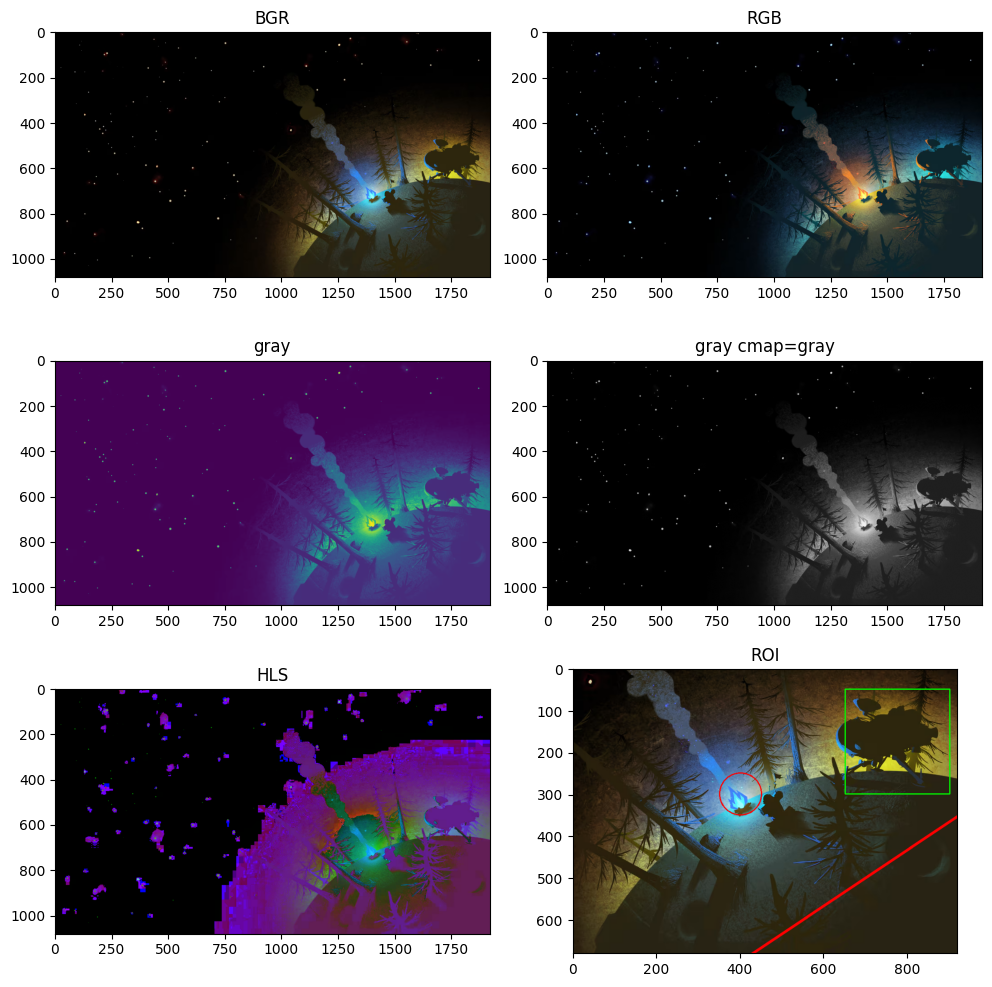

In [5]:
fig, ax = plt.subplots(3, 2)
fig.set_figwidth(10)
fig.set_figheight(10)
fig.tight_layout()

ax[0,0].set_title("BGR")
ax[0,0].imshow(img2_bgr)
ax[0,1].set_title("RGB")
ax[0,1].imshow(img2_rgb)
ax[1,0].set_title("gray")
ax[1,0].imshow(img2_gray)
ax[1,1].set_title("gray cmap=gray")
ax[1,1].imshow(img2_gray, cmap="gray", vmin=0, vmax=255)
ax[2,0].set_title("HLS")
ax[2,0].imshow(img2_hls)
ax[2,1].set_title("ROI")
ax[2,1].imshow(img2_roi);

## Dibujado por mouse (solo en escritorio)

In [ ]:
clone = img_bgr.copy()

clicked = False # False: estado inicial -[click]-> True: primer punto seleccionado
p1 = (-1, -1)

def click_event(event, x, y, flags, param):
    global clicked, p1
    if event == cv2.EVENT_LBUTTONDOWN:
        if clicked: # segundo click
            clicked = False
            cv2.rectangle(img_bgr, p1, (x, y), (0,255,0), 2)
        else:   # primer click
            clicked = True
            p1 = (x, y)

cv2.namedWindow('Ej 1')
cv2.setMouseCallback('Ej 1', click_event)

while True:
    cv2.imshow('Ej 1', img_bgr)
    if cv2.waitKey(1) & 0xFF == 27: # 27: ESC en ASCII
        break

cv2.destroyAllWindows()

# Ejercicio 2

1. Informe los valores de intensidad de puntos particulares de la imagen (opcional: determine la posición en base al click del mouse).
2. Obtenga y grafique los valores de intensidad (*perfil de intensidad*) sobre una determinada fila o columna.
3. Grafique el *perfil de intensidad* para un segmento de interés cualquiera.

## Perfil de intensidad en una fila y columna

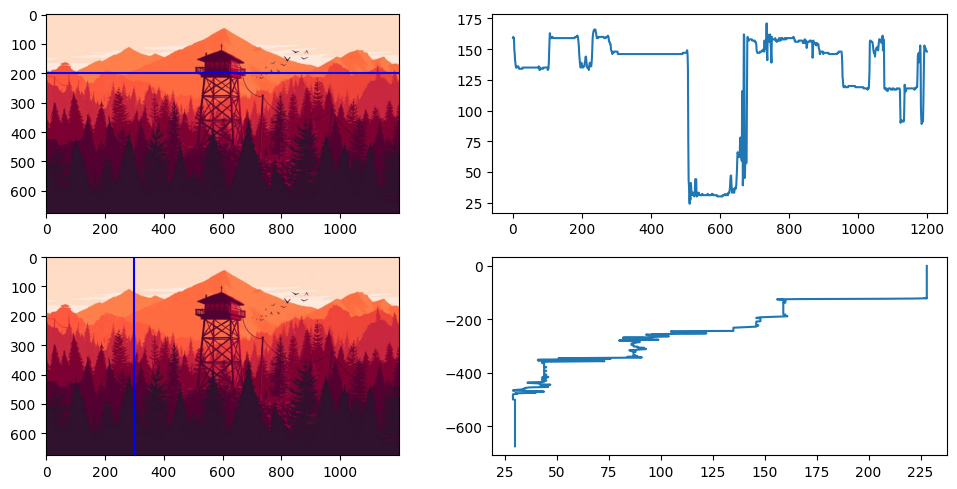

In [3]:
img = cv2.imread("imagenes/firewatch.png")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

row = 200
col = 300

fig, ax = plt.subplots(2, 2)
fig.set_figwidth(10)
fig.set_figheight(5)

ax[0,0].imshow(img_rgb)
ax[0,0].plot([0, img_rgb.shape[1]-1], [row, row], c="blue")
ax[0,1].plot(img_gray[row,:])
ax[1,0].imshow(img_rgb)
ax[1,0].plot([col, col], [0, img_rgb.shape[0]-1], c="blue")
ax[1,1].plot(img_gray[:,col], -np.arange(img_gray.shape[0]))
fig.tight_layout()

## Perfil de intensidad en un segmento

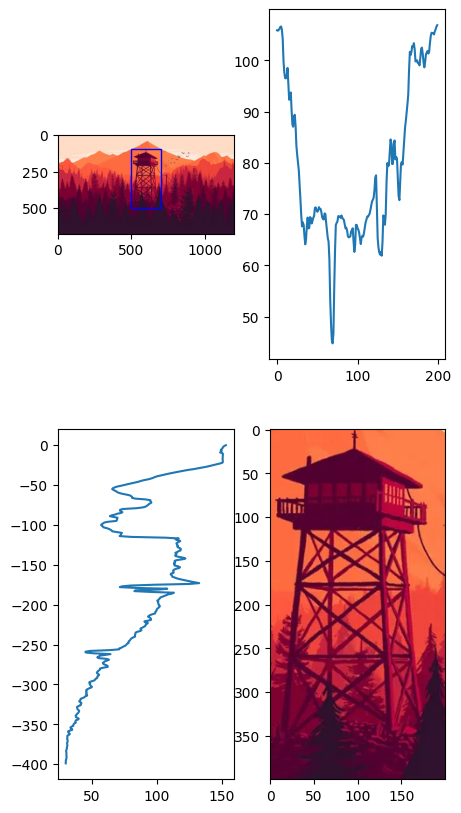

In [4]:
# (100,300), (300,50)
x,y,w,h = 500, 100, 200, 400
roi = img_rgb[y:y+h, x:x+w]
roi_gray = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY)

fig, ax = plt.subplots(2,2)
fig.set_figwidth(5)
fig.set_figheight(10)
ax[0,0].imshow(img_rgb)
ax[0,0].add_patch(plt.Rectangle((x,y), w, h, edgecolor='blue', linewidth=1, fill=False))
ax[1,1].imshow(roi)
ax[0,1].plot(np.mean(roi_gray, axis=0)) # promedio horizontal
ax[1,0].plot(np.mean(roi_gray, axis=1), -np.arange(roi_gray.shape[0])); # promedio vertical

## Intensidad en puntos particulares

In [5]:
def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        # intensidad (por la escala de grises)
        I = img_gray[y, x]
        print(f"Posicion ({x}, {y}) - Intensidad {I}")

cv2.imshow('Ej 1', img) # se muestra la original
cv2.setMouseCallback('Ej 1', click_event)
cv2.waitKey(0)
cv2.destroyAllWindows()

DisabledFunctionError: cv2.imshow() is disabled in Colab, because it causes Jupyter sessions
to crash; see https://github.com/jupyter/notebook/issues/3935.
As a substitution, consider using
  from google.colab.patches import cv2_imshow


# Ejercicio 3

Utilice las herramientas aprendidas en esta unidad para implementar un sistema que permita identificar una botella que no est´correctamente llena. Las imágenes que se proporcionarán son capturadas con una cámara fija, en escala de grises y directamente de la línea de envasado. Para implementar el sistema deberá bastarle una imagen de ejemplo "botella.tif" (que encontrará en el repositorio). Adicionalmentem se espera que el sistema pueda:

- Identificar una botella *no-llena* en cualquier posición de la imagen
- Indicar la posición de la botella en la imagen (podría ser con un recuadro, informando la posición relativa entre botellas, la posición absoluta en píxeles, etc).
- Informar el porcentaje de llenado de la botella *no-llena*.

## Cargar librerias e imagen

In [6]:
# imagen
img = cv2.imread("imagenes/botellas.tif")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

## Detectar posicion horizontal

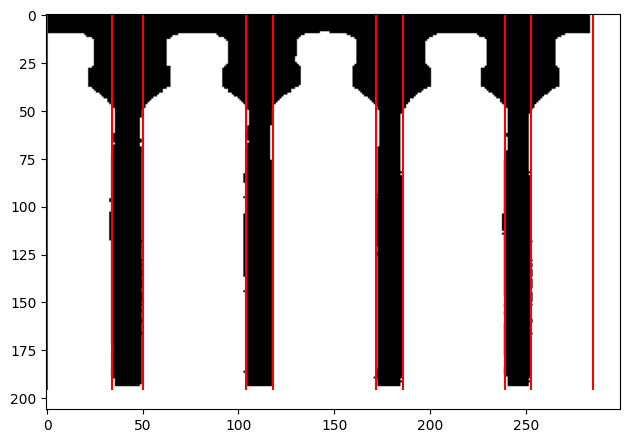

In [7]:
# imagen con valores binarios segun un umbral
img_silueta = np.where(np.greater(img_gray, 10), 1, 0)

# Detectar posicion horizontal de las botellas
# Se realiza un "scanline" a la altura de y=100
botellas = []

init = -1
i = 0
while i < img_silueta.shape[1]:
    # detectar cuando "empieza" una botella
    if img_silueta[100,i] == 1:
        init = i

        # buscar cuando "termina" una botella (o la imagen)
        j = i
        while j < img_silueta.shape[1] and img_silueta[100, j] == 1:
            j += 1
        botellas.append({
            'x': [init, j],
            'y': [],
            'llenado': 0.0,
        })
        i = j
    i += 1

# graficar
fig, ax = plt.subplots(1,1)

ax.imshow(img_silueta, cmap="gray")

for botella in botellas:
    ax.vlines(botella['x'][0], 0, img_silueta.shape[0], colors="r")
    ax.vlines(botella['x'][1], 0, img_silueta.shape[0], colors="r")

fig.tight_layout()

## Detectar posicion vertical

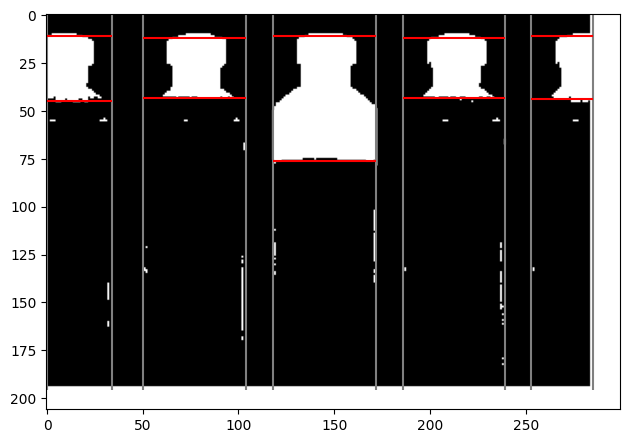

In [8]:
# Detectar posicion vertical
# se aplica un umbral a la imagen para exagerar los "limites"
img_threshold = np.where(np.greater(img_gray, 200), 1, 0)
for botella in botellas:
    # promedio horizontal
    prom_x = np.mean(img_threshold[:, botella['x'][0]:botella['x'][1]], axis=1)
    j = 0
    while j < prom_x.shape[0]:
        # detectamos la parte superior de la botella
        if prom_x[j] > 0.4:
            tapa = j
            # buscamos el nivel del liquido
            k = j
            while k < prom_x.shape[0] and prom_x[k] > 0.4:
                k += 1
            # guardamos los niveles de la botella
            botella['y'] = [tapa, k]
            break
        j += 1

# graficar
fig, ax = plt.subplots(1,1)

ax.imshow(img_threshold, cmap="gray")

for botella in botellas:
    ax.vlines(botella['x'][0], 0, img_threshold.shape[0], colors="gray")
    ax.vlines(botella['x'][1], 0, img_threshold.shape[0], colors="gray")
    ax.hlines(botella['y'][0], botella['x'][0], botella['x'][1], colors="r")
    ax.hlines(botella['y'][1], botella['x'][0], botella['x'][1], colors="r")

fig.tight_layout()


## Medir llenado

In [9]:
for botella in botellas:
    # inversa de la proporcion de vacio vs total
    botella['llenado'] = 1 - (botella['y'][1] - botella['y'][0])/(img.shape[0] - botella['y'][0])

## Resultado

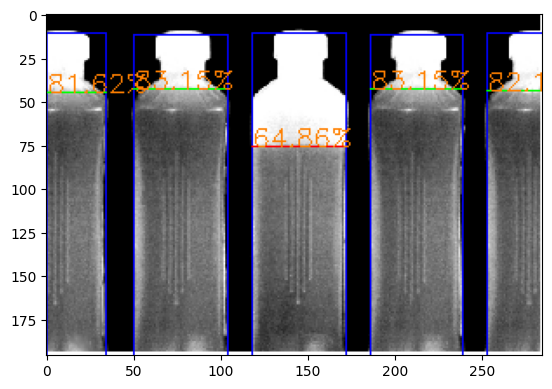

In [10]:
# Dibujar datos de las botellas
for botella in botellas:
    # dibujar contorno de las botellas
    cv2.rectangle(img, (botella['x'][0], botella['y'][0]), (botella['x'][1], img.shape[0]), (0, 0, 255), 1)

    # dibujar nivel del liquido
    cv2.line(img, (
        botella['x'][0],
        botella['y'][1]),
        (botella['x'][1], botella['y'][1]),
        (255, 0, 0) if botella['llenado'] < 0.8 else (0, 255, 0),
        1
    )

    # porcentaje de llenado
    cv2.putText(
        img,
        "{:.2f}%".format(botella['llenado']*100),
        (botella['x'][0], botella['y'][1]),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 128, 0),
        1
    )

# visualizacion test
fig, ax = plt.subplots(1, 1)

ax.imshow(img, cmap="gray");